In [1]:
from platform import python_version

print(python_version())

3.9.2


In [2]:
import os
import time
import glob
#import opensimplex

#from torchvision.utils import save_image

import matplotlib.pyplot as plt
import numpy as np
import csv
import torch
import torch.nn.functional as F
from monai import transforms
from monai.data import CacheDataset, DataLoader, Dataset
from monai.utils import set_determinism
from monai.data.utils import pad_list_data_collate
from torch.amp import GradScaler, autocast
from tqdm import tqdm
import random

import nibabel as nib

from monai.inferers import DiffusionInferer
from monai.networks.nets import DiffusionModelUNet
from monai.networks.schedulers import DDPMScheduler

import pandas as pd
import AnoDDPM.simplex as simplex

from monai.metrics import compute_iou

#print_config()

/bettik/PROJECTS/pr-gin5_aini/fehrdelt/environments/ddpm_env/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
DEVICE_TYPE = "cuda:0"

In [4]:
torch.cuda.current_device()


0

In [5]:
cuda_available = torch.cuda.is_available()
print(f"CUDA is available: {cuda_available}")

CUDA is available: True


In [6]:
#ROOT_DIR = "/home/fehrdelt/bettik/"
ROOT_DIR = "/bettik/PROJECTS/pr-gin5_aini/fehrdelt/"

In [7]:
set_determinism(0)

## Setup Dallas Healthy Lifespan ADC Dataset and training and validation dataloaders

2D 128x128 slices of 3D ADC volumes

In [8]:
IMAGE_SIZE = 128

In [9]:
train_csv = os.path.join(ROOT_DIR, "AnoDiffExperiments/data_splits_lists/ADC_Dallas_and_HCP-YA/train.csv")
train_images_path = []

with open(train_csv, mode='r') as file:
    reader = csv.reader(file)
    for line in tqdm(reader):
        #print(line)
        train_images_path.append(ROOT_DIR+line[0])

val_csv = os.path.join(ROOT_DIR, "AnoDiffExperiments/data_splits_lists/ADC_Dallas_and_HCP-YA/val.csv")
val_images_path = []

with open(val_csv, mode='r') as file:
    reader = csv.reader(file)
    for line in tqdm(reader):

        val_images_path.append(ROOT_DIR+line[0])

test_reconstruction_csv = os.path.join(ROOT_DIR, "AnoDiffExperiments/data_splits_lists/ADC_Dallas_and_HCP-YA/test.csv")
test_reconstruction_images_path = []

with open(test_reconstruction_csv, mode='r') as file:
    reader = csv.reader(file)
    for line in tqdm(reader):

        test_reconstruction_images_path.append(ROOT_DIR+line[0])


1572it [00:00, 293681.61it/s]
197it [00:00, 112525.93it/s]
197it [00:00, 152703.36it/s]


In [10]:
#train_datalist = sorted(train_images_path)
train_datalist = train_images_path

#val_datalist = sorted(val_images_path)
val_datalist = val_images_path

#val_datalist = sorted(val_images_path)
test_reconstruction_datalist = test_reconstruction_images_path

#test_unhealthy_datalist = test_unhealthy_images_path

batch_size = 32
num_workers = 4


In [11]:
train_datalist[0]

'/bettik/PROJECTS/pr-gin5_aini/fehrdelt/datasets/ADC_Human_Connectome_Project_Young_Adult_HCP-YA_resized128/205119.nii.gz'

In [12]:
class Get2DSlice(transforms.Transform):
    """
    Fetch the middle slice of a 3D volume.
    Args:
        axis: The axis along which to slice the volume. 0 for axial, 1 for coronal, 2 for sagittal.
        offset : Offset the index by a specified amount (default=0)
    """

    def __init__(
        self,
        axis: int = 0,
        offset: int=0
    ):
        super().__init__()
        self.axis = axis
        self.offset = offset

    def __call__(self, data):
        #print(data.shape)
        if self.axis==0:
            return data[:, data.shape[1]//2+self.offset,:,:]
        elif self.axis==1:
            return data[:, :,data.shape[2]//2+self.offset,:]
        elif self.axis==2:
            return data[:, :, :,data.shape[3]//2+self.offset]

In [ ]:
class Get2DSliceWithRandomOffset(transforms.RandomizableTransform):
    """
    Will return the middle slice with a random offset in addition to the specified fixed offset.
    Args:
        axis: The axis along which to slice the volume. 0 for axial, 1 for coronal, 2 for sagittal.
        offset : Offset the index by a specified amount (default=0)
    """

    def __init__(
        self,
        axis: int = 0,
        fixed_offset: int=0
    ):
        super().__init__()
        self.axis = axis
        self.fixed_offset = fixed_offset
        self.rand_offset = 0


    def randomize(self):
        super().randomize(None)
        self.rand_offset = random.randint(-5, 5)

    def __call__(self, data):
        #print(data.shape)
        self.randomize()

        if self.axis==0:
            return data[:, data.shape[1]//2+self.fixed_offset+self.rand_offset,:,:]
        elif self.axis==1:
            return data[:, :,data.shape[2]//2+self.fixed_offset+self.rand_offset,:]
        elif self.axis==2:
            return data[:, :, :,data.shape[3]//2+self.fixed_offset+self.rand_offset]

In [20]:
class SetBackgroundToZero(transforms.Transform):
    """
    Custom MONAI transform that zeros out voxels with the most frequent intensity value.
    
    Args:
        keys (str or list): Keys of the dictionary to apply the transform to.
        tolerance (int): Optional range around the mode value to also zero.
    """
    def __init__(self, tolerance: int = 0):
        super().__init__()
        self.tolerance = tolerance

    def __call__(self, data):
        
            
        is_tensor = isinstance(data, torch.Tensor)
        data_np = data.cpu().numpy() if is_tensor else data

        # Flatten and compute histogram
        flat = data_np.flatten()
        unique, counts = np.unique(flat, return_counts=True)
        mode_val = unique[np.argmax(counts)]

        # Apply tolerance if specified
        if self.tolerance > 0:
            mask = np.isin(data_np, range(mode_val - self.tolerance, mode_val + self.tolerance + 1))
        else:
            mask = data_np == mode_val

        # Zero out the background
        data_np[mask] = 0

        # Put back in original type
        data = torch.from_numpy(data_np) if is_tensor else data_np

        return data

In [21]:
print(train_datalist[1])

/bettik/PROJECTS/pr-gin5_aini/fehrdelt/datasets/Dallas_ADC_rotated_resampled_registered/sub-3727_ses-wave1_ADC.nii.gz


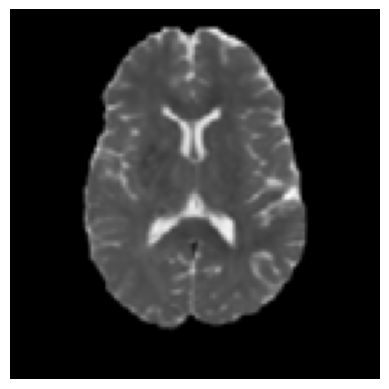

In [22]:
import numpy as np

img = nib.load(train_datalist[0])

img_data = img.get_fdata()
middle_slice = img_data[:, :, img_data.shape[2] // 2]

plt.imshow(middle_slice, cmap="gray")
plt.axis("off")
plt.show()

In [23]:
train_transforms = transforms.Compose(
    [
        transforms.LoadImage(image_only=True),
        transforms.EnsureChannelFirst(),
        transforms.RandAffine(prob=0.2, rotate_range=(0.15, 0.15, 0.15)),#+- 0.15 radians for each axis
        Get2DSliceWithRandomOffset(axis=2, fixed_offset=0), #28
        transforms.ScaleIntensityRange(a_min=0.0, a_max=4000.0, b_min=0.0, b_max=1.0, clip=True),
        transforms.RandScaleCrop(roi_scale=0.9, max_roi_scale=1.1, random_size=True),
        transforms.ResizeWithPadOrCrop(spatial_size=(128, 128)),
    ]
)
train_ds = CacheDataset(data=train_datalist[:batch_size], transform=train_transforms) #TODO datalist[:32]
train_loader = DataLoader(
    #collate_fn=pad_list_data_collate: any tensors are centrally padded to match the shape of the biggest tensor in each dimension
    train_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers, persistent_workers=True, collate_fn=pad_list_data_collate
)

Loading dataset: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 32/32 [00:01<00:00, 21.75it/s]


In [18]:

val_transforms = transforms.Compose(
    [
        transforms.LoadImage(),
        transforms.EnsureChannelFirst(),
        Get2DSlice(axis=2, offset=0),  # 28
        transforms.ScaleIntensityRange(a_min=0.0, a_max=4000.0, b_min=0.0, b_max=1.0, clip=True),
        transforms.ResizeWithPadOrCrop(spatial_size=(128, 128)),
    ]
)
val_ds = CacheDataset(data=val_datalist, transform=val_transforms)
val_loader = DataLoader(
    val_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers, persistent_workers=True
)


Loading dataset: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 197/197 [00:09<00:00, 20.61it/s]


In [19]:
test_reconstruction_transforms = transforms.Compose(
    [
        transforms.LoadImage(),
        transforms.EnsureChannelFirst(),
        Get2DSlice(axis=2, offset=0),
        transforms.ScaleIntensityRange(a_min=0.0, a_max=4000.0, b_min=0.0, b_max=1.0, clip=True),
        transforms.ResizeWithPadOrCrop(spatial_size=(128, 128)),
    ]
)
test_reconstruction_ds = CacheDataset(data=test_reconstruction_datalist, transform=test_reconstruction_transforms)
test_reconstruction_loader = DataLoader(
    test_reconstruction_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers, persistent_workers=True
)

Loading dataset: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 197/197 [00:09<00:00, 20.67it/s]


torch.Size([1, 128, 128, 107])
torch.Size([1, 128, 128, 128])
torch.Size([1, 128, 128, 128])
torch.Size([1, 128, 128, 128])
torch.Size([1, 128, 128, 107])
torch.Size([1, 128, 128, 128])
torch.Size([1, 128, 128, 128])
torch.Size([1, 128, 128, 128])
torch.Size([1, 128, 128, 107])
torch.Size([1, 128, 128, 128])
torch.Size([1, 128, 128, 128])
torch.Size([1, 128, 128, 107])
torch.Size([1, 128, 128, 128])
torch.Size([1, 128, 128, 107])
torch.Size([1, 128, 128, 107])
torch.Size([1, 128, 128, 128])
torch.Size([1, 128, 128, 107])
torch.Size([1, 128, 128, 128])
torch.Size([1, 128, 128, 107])
torch.Size([1, 128, 128, 128])
torch.Size([1, 128, 128, 107])
torch.Size([1, 128, 128, 107])
torch.Size([1, 128, 128, 128])
torch.Size([1, 128, 128, 107])
torch.Size([1, 128, 128, 107])
torch.Size([1, 128, 128, 107])
torch.Size([1, 128, 128, 128])
torch.Size([1, 128, 128, 128])
torch.Size([1, 128, 128, 128])
torch.Size([1, 128, 128, 128])
torch.Size([1, 128, 128, 128])
torch.Size([1, 128, 128, 107])
batch sh

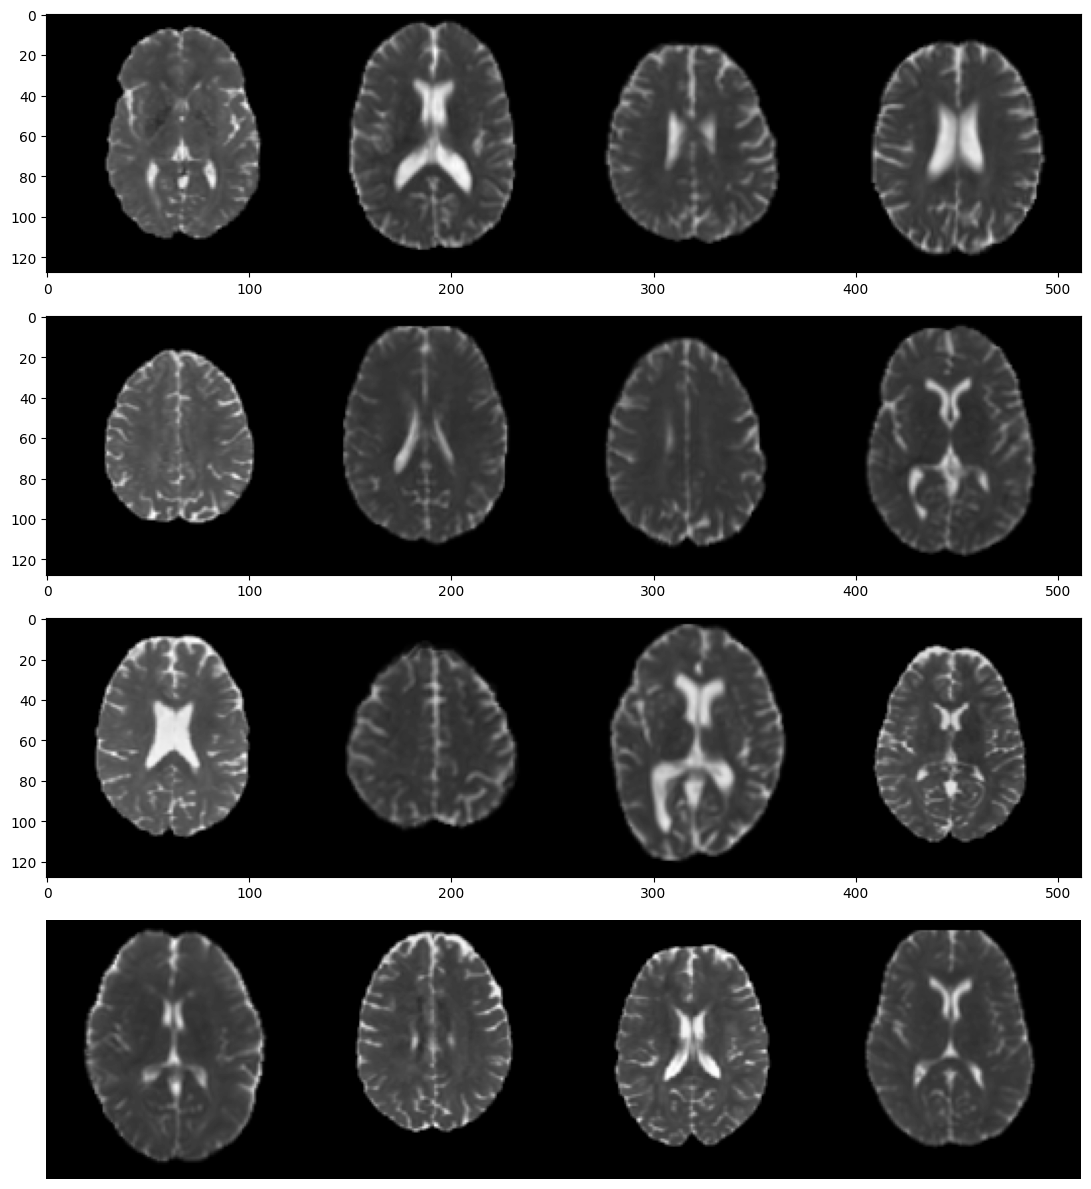

In [ ]:

for i, batch in enumerate(train_loader):
    #print(i)
    if i>=0:break

    print(f"batch shape: {batch.shape}")
    image_visualisation0 = torch.cat(
        [batch[0, 0], batch[1, 0], batch[2, 0], batch[3, 0]], dim=1
    )
    image_visualisation1 = torch.cat(
        [batch[4, 0], batch[5, 0], batch[6, 0], batch[7, 0]], dim=1
    )
    image_visualisation2 = torch.cat(
        [batch[8, 0], batch[9, 0], batch[10, 0], batch[11, 0]], dim=1
    )
    image_visualisation3 = torch.cat(
        [batch[12, 0], batch[13, 0], batch[14, 0], batch[15, 0]], dim=1
    )
    fig, (ax0, ax1, ax2, ax3) = plt.subplots(4,figsize=(12, 12))
    
    ax0.imshow(image_visualisation0, cmap="gray")
    ax1.imshow(image_visualisation1, cmap="gray")
    ax2.imshow(image_visualisation2, cmap="gray")
    ax3.imshow(image_visualisation3, cmap="gray")
    plt.axis("off")
    plt.tight_layout()
    plt.show()



### Opensimplex noise 

https://code.larus.se/lmas/opensimplex 

https://pypi.org/project/opensimplex/

https://github.com/Julian-Wyatt/AnoDDPM/blob/master/simplex.py#L212

https://openaccess.thecvf.com/content/CVPR2022W/NTIRE/papers/Wyatt_AnoDDPM_Anomaly_Detection_With_Denoising_Diffusion_Probabilistic_Models_Using_Simplex_CVPRW_2022_paper.pdf

AnoDDPM:

Instead of using the default simplex noise function, we
can apply a number of octaves of noise (also known as frac-
tal noise). This involves combining N frequencies of noise
together, where the next frequency’s amplitude reduces by
some decay rate γ. Figure 2b shows that low frequency
noise cannot be well approximated with a Gaussian distri-
bution; however, by applying an increasing number of oc-
taves of noise, the distribution becomes closer to a Gaussian
distribution. This is paramount for our DDPM model as we
assume our noising function is sampling from a Gaussian
distribution. Therefore, unless stated otherwise, we use a
starting frequency of ν = 2^6 (et pas 2^(-6) comme écrit dans l'article), octave of N = 6 and a de-
cay of γ = 0.8. Furthermore, when generating the simplex
noise, we shuffle the seed before every noise calculation,
and take a slice t from the 3-dimensional noise function,
as we found that artefacts were introduced when sampling
from the 2-dimensional noise function

"""
            Returns a layered fractal noise in 2D\
        :param shape: Shape of 2D tensor output\
        :param octaves: Number of levels of fractal noise\
        :param persistence: float between (0-1) -> Rate at which amplitude of each level decreases\
        :param frequency: Frequency of initial octave of noise\
        :return: Fractal noise sample with n lots of 2D images
        """

! need to do `pip install simplex`

!!! **shuffle the seed before every noise calculation (if timestep = 100: 100 shuffles)**,


and take a slice t from the 3-dimensional noise function,
as we found that artefacts were introduced when sampling
from the 2-dimensional noise function

In [19]:

def generate_simplex_noise(simplexObj, shape):
    """Generate spatially correlated simplex noise."""

    simplexObj.newSeed()

    if len(shape) ==2:
        # take a slice t from the 3-dimensional noise function as we found that artefacts 
        # were introduced when sampling from the 2-dimensional noise function
        simplex = simplexObj.rand_3d_octaves(shape=(shape[0], shape[0], shape[1]), octaves=6, persistence=0.8, frequency=64)[12,...]
    elif len(shape) == 3:
        simplex = simplexObj.rand_3d_octaves(shape=shape, octaves=6, persistence=0.8, frequency=64)
    elif len(shape) == 4 and shape[1] == 1: # to make it work with shapes of type (batch_size, 1, height, width)
        simplex = simplexObj.rand_3d_octaves(shape=(shape[0], shape[2], shape[3]), octaves=6, persistence=0.8, frequency=64)
        simplex = np.expand_dims(simplex, axis=1)

    return torch.tensor(simplex, dtype=torch.float32)

In [20]:
from monai.utils import StrEnum
from typing import Union

class DDPMPredictionType(StrEnum):
    """
    Set of valid prediction type names for the DDPM scheduler's `prediction_type` argument.

    epsilon: predicting the noise of the diffusion process
    sample: directly predicting the noisy sample
    v_prediction: velocity prediction, see section 2.4 https://imagen.research.google/video/paper.pdf
    """

    EPSILON = "epsilon"
    SAMPLE = "sample"
    V_PREDICTION = "v_prediction"

class SimplexDDPMScheduler(DDPMScheduler):
    def __init__(self, *args, noise_scale=1.0, **kwargs):
        super().__init__(*args, **kwargs)
        self.noise_scale = noise_scale
        self.simplex_obj = simplex.Simplex_CLASS()
        self.simplex_obj.newSeed()

    #def step(
    #    self, model_output: torch.Tensor, timestep: int, sample: torch.Tensor, generator: torch.Generator | None = None
    #) -> tuple[torch.Tensor, torch.Tensor]:
    def step(
        self, model_output: torch.Tensor, timestep: int, sample: torch.Tensor, generator: Union[torch.Generator, None] = None
    ) -> tuple[torch.Tensor, torch.Tensor]:
        """
        Predict the sample at the previous timestep by reversing the SDE. Core function to propagate the diffusion
        process from the learned model outputs (most often the predicted noise).

        Args:
            model_output: direct output from learned diffusion model.
            timestep: current discrete timestep in the diffusion chain.
            sample: current instance of sample being created by diffusion process.
            generator: random number generator.

        Returns:
            pred_prev_sample: Predicted previous sample
        """
        if model_output.shape[1] == sample.shape[1] * 2 and self.variance_type in ["learned", "learned_range"]:
            model_output, predicted_variance = torch.split(model_output, sample.shape[1], dim=1)
        else:
            predicted_variance = None

        # 1. compute alphas, betas
        alpha_prod_t = self.alphas_cumprod[timestep]
        alpha_prod_t_prev = self.alphas_cumprod[timestep - 1] if timestep > 0 else self.one
        beta_prod_t = 1 - alpha_prod_t
        beta_prod_t_prev = 1 - alpha_prod_t_prev

        # 2. compute predicted original sample from predicted noise also called
        # "predicted x_0" of formula (15) from https://arxiv.org/pdf/2006.11239.pdf
        if self.prediction_type == DDPMPredictionType.EPSILON:
            pred_original_sample = (sample - beta_prod_t ** (0.5) * model_output) / alpha_prod_t ** (0.5)
        elif self.prediction_type == DDPMPredictionType.SAMPLE:
            pred_original_sample = model_output
        elif self.prediction_type == DDPMPredictionType.V_PREDICTION:
            pred_original_sample = (alpha_prod_t**0.5) * sample - (beta_prod_t**0.5) * model_output

        # 3. Clip "predicted x_0"
        if self.clip_sample:
            pred_original_sample = torch.clamp(
                pred_original_sample, self.clip_sample_values[0], self.clip_sample_values[1]
            )

        # 4. Compute coefficients for pred_original_sample x_0 and current sample x_t
        # See formula (7) from https://arxiv.org/pdf/2006.11239.pdf
        pred_original_sample_coeff = (alpha_prod_t_prev ** (0.5) * self.betas[timestep]) / beta_prod_t
        current_sample_coeff = self.alphas[timestep] ** (0.5) * beta_prod_t_prev / beta_prod_t

        # 5. Compute predicted previous sample µ_t
        # See formula (7) from https://arxiv.org/pdf/2006.11239.pdf
        pred_prev_sample = pred_original_sample_coeff * pred_original_sample + current_sample_coeff * sample

        # 6. Add noise
        variance: torch.Tensor = torch.tensor(0)
        if timestep > 0:
            self.simplex_obj.newSeed()
            noise = generate_simplex_noise(self.simplex_obj, shape=model_output.size()).to(model_output.device)
            
            """ #TODO
            noise = torch.randn(
                model_output.size(),
                dtype=model_output.dtype,
                layout=model_output.layout,
                generator=generator,
                device=model_output.device,
            )"""
            variance = (self._get_variance(timestep, predicted_variance=predicted_variance) ** 0.5) * noise

        pred_prev_sample = pred_prev_sample + variance

        return pred_prev_sample, pred_original_sample

In [23]:
device = torch.device(DEVICE_TYPE)
simplexObj = simplex.Simplex_CLASS()


model = DiffusionModelUNet(
    spatial_dims=2,
    in_channels=1,
    out_channels=1,
)
model.to(device)

num_train_timesteps = 1000
scheduler = SimplexDDPMScheduler(num_train_timesteps=num_train_timesteps)

optimizer = torch.optim.Adam(params=model.parameters(), lr=2.5e-5)

inferer = DiffusionInferer(scheduler)

### Anomaly Map
https://github.com/Project-MONAI/tutorials/blob/main/generation/anomaly_detection/anomaly_detection_with_transformers.ipynb

In [24]:
model.load_state_dict(torch.load(os.path.join(ROOT_DIR+"AnoDiffExperiments/best_models/experiment_3", "exp_3_2_best_model.pth"), map_location=DEVICE_TYPE))
model.eval()

DiffusionModelUNet(
  (conv_in): Convolution(
    (conv): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  )
  (time_embed): Sequential(
    (0): Linear(in_features=32, out_features=128, bias=True)
    (1): SiLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
  )
  (down_blocks): ModuleList(
    (0): DownBlock(
      (resnets): ModuleList(
        (0-1): 2 x DiffusionUNetResnetBlock(
          (norm1): GroupNorm(32, 32, eps=1e-06, affine=True)
          (nonlinearity): SiLU()
          (conv1): Convolution(
            (conv): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          )
          (time_emb_proj): Linear(in_features=128, out_features=32, bias=True)
          (norm2): GroupNorm(32, 32, eps=1e-06, affine=True)
          (conv2): Convolution(
            (conv): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          )
          (skip_connection): Identity()
        )
      )
      (downsampler): Diffus

In [25]:
ISLES_ADC_datalist = sorted(glob.glob(ROOT_DIR+"datasets/ISLES_ADC_registered_resampled/*.nii.gz"))

problematic_images_indexes = [59,100,101,136,152,153,161,163,164,165,166,181,183,184,185,187,188,190,192, #TODO: va falloir régler les pb sur ces images, ça a l'air d'être la partie ou je fais rotate90 qui foire (peut être avec le remplacement de la matrice affine)
                              193,194,196,198,199,201,205,206,207,208,214,218,221,225,228,229,235,237,238,
                              240,242,244,247,248,249]
problematic_images = [os.path.basename(ISLES_ADC_datalist[i]) for i in problematic_images_indexes]
ISLES_ADC_datalist = [image for image in ISLES_ADC_datalist if os.path.basename(image) not in problematic_images]

#print(ISLES_ADC_datalist[:10])
ISLES_masks_datalist = sorted(glob.glob(ROOT_DIR+"datasets/ISLES_masks_registered_resampled/*.nii.gz"))
ISLES_masks_datalist = [image for image in ISLES_masks_datalist]
ISLES_masks_datalist = [image for image in ISLES_masks_datalist if os.path.basename(image).replace('msk', 'adc') not in problematic_images]
#print(ISLES_masks_datalist[:10])
#print(problematic_images)

In [26]:
img_isles_to_keep = [0,2,3,9,10,12,14,16,20,21,22,23,25,26,
                     30,32,37,38,39,40,42,46,47,48,51,52,53,
                     55,56,60,62,63,64,65,72,74,75,79, 80,81,
                     82,83,85,90,93,103,104,110,112,114,116,118,
                     120,123,125,135,140,141,147,148,151,154,155,
                     156,157,159164,166,167,168,170,171,172,173,175,176,178,
                     180,181,84,187,188,190,192,194,199,200,201,202,203,204,205]

ISLES_ADC_datalist_final = [] # only the images where there is a lesion on the middle slice
ISLES_masks_datalist_final = []
 
for i, element in enumerate(ISLES_ADC_datalist):
    if i not in img_isles_to_keep:
        pass
    else:
        ISLES_ADC_datalist_final.append(element)
        ISLES_masks_datalist_final.append(ISLES_masks_datalist[i])
        

In [27]:
num_workers = 4
ano_batch_size = 10


In [40]:
for i in range(4):
    img = nib.load(ISLES_ADC_datalist_final[i])
    print(f"Image {i} shape: {img.shape}")

Image 0 shape: (128, 128, 128)
Image 1 shape: (128, 128, 128)
Image 2 shape: (128, 128, 128)
Image 3 shape: (128, 128, 128)


In [34]:
num_workers = 4
ano_batch_size = 16

test_anomaly_transforms = transforms.Compose(
    [
        transforms.LoadImage(),
        transforms.EnsureChannelFirst(),
        Get2DSlice(axis=2, offset=+2),
        transforms.ScaleIntensity(minv=0.0, maxv=3000.0),
        transforms.ScaleIntensityRange(a_min=0.0, a_max=3200.0, b_min=0.0, b_max=1.0, clip=True), # change a_max to increase or decrease intensity of the images after transformation
        transforms.ResizeWithPadOrCrop(spatial_size=(128, 128)),
        SetBackgroundToZero(tolerance=0),  # Set background to zero
    ]
)
test_anomaly_ds = CacheDataset(data=ISLES_ADC_datalist_final, transform=test_anomaly_transforms) # TODO ISLES_ADC_datalist[:10]


test_anomaly_loader = DataLoader(
    test_anomaly_ds, batch_size=ano_batch_size, shuffle=False, num_workers=num_workers, persistent_workers=True
)


Loading dataset: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 90/90 [00:09<00:00,  9.65it/s]


In [35]:

test_masks_transforms = transforms.Compose(
    [
        transforms.LoadImage(),
        transforms.EnsureChannelFirst(),
        Get2DSlice(axis=2, offset=+2),
        transforms.ResizeWithPadOrCrop(spatial_size=(128, 128)),
    ]
)
test_masks_ds = CacheDataset(data=ISLES_masks_datalist_final, transform=test_masks_transforms) # TODO ISLES_ADC_datalist[:10]


test_masks_loader = DataLoader(
    test_masks_ds, batch_size=ano_batch_size, shuffle=False, num_workers=num_workers, persistent_workers=True
)

Loading dataset:   0%|                                                                                                                           | 0/90 [00:00<?, ?it/s]

Loading dataset: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 90/90 [00:06<00:00, 13.99it/s]


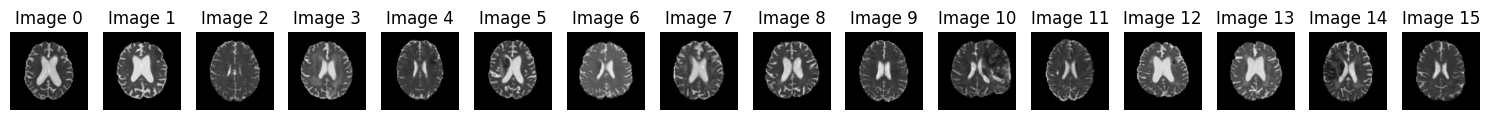

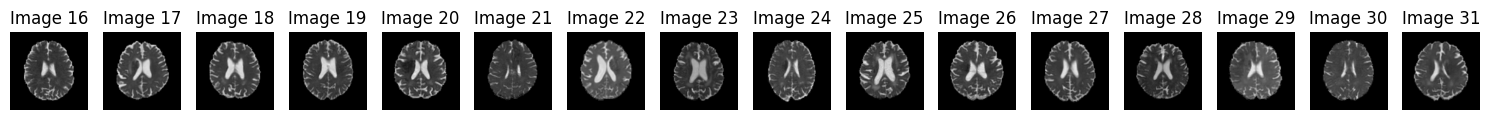

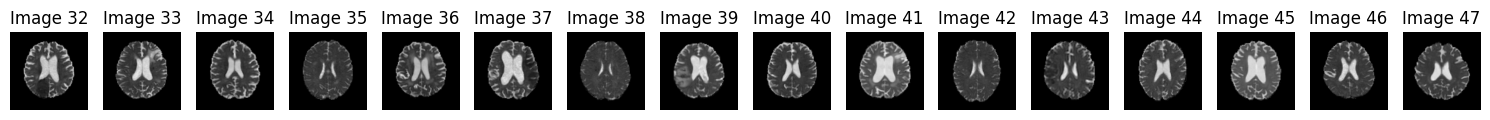

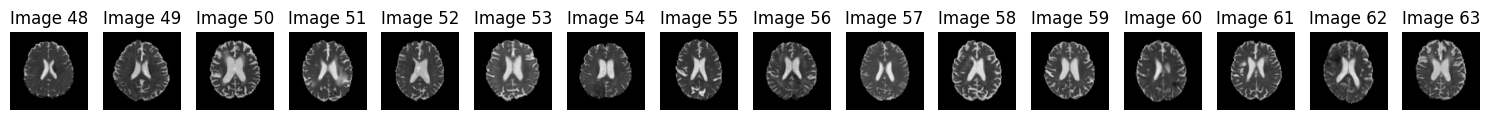

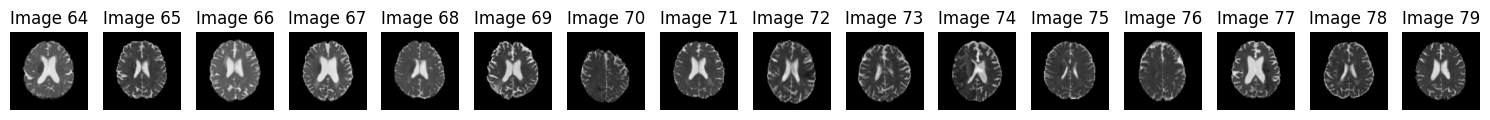

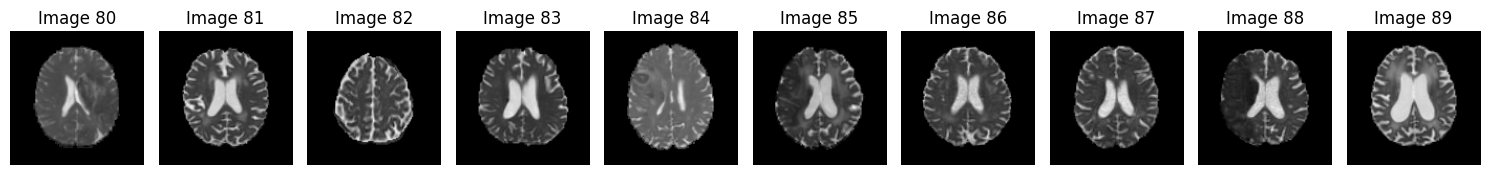

In [36]:

for batch_number, batch in enumerate(test_anomaly_loader):
    num_images = batch.shape[0]
    fig, axs = plt.subplots(1, num_images, figsize=(15, 5))
    for i in range(num_images):
        img = batch[i, 0].cpu().numpy()
        axs[i].imshow(img, cmap="gray", vmin=0, vmax=1)
        axs[i].axis("off")
        axs[i].title.set_text(f"Image {batch_number*ano_batch_size + i}")
    plt.tight_layout()
    plt.show()

In [37]:

@torch.no_grad()
def my_sample(image, timesteps=100, progress_bar=True):
    
    
    num_infer_timesteps = timesteps #100 # higher number = more noise at first timestep, more denoising steps
    intermediate_steps = num_infer_timesteps//10
    infer_scheduler = SimplexDDPMScheduler(num_train_timesteps=num_infer_timesteps)

    all_next_timesteps = torch.cat((scheduler.timesteps[1:], torch.tensor([0], dtype=infer_scheduler.timesteps.dtype)))

    if progress_bar:
        progress_bar = tqdm(
            zip(infer_scheduler.timesteps, all_next_timesteps),
            total=min(len(infer_scheduler.timesteps), len(all_next_timesteps)),
        )
    else:
        progress_bar = zip(infer_scheduler.timesteps, all_next_timesteps)
            
    intermediates = []
            
    for t, next_t in progress_bar:          # va de num_infer_timesteps à 0
        # 1. predict noise model_output
        diffusion_model = model
        
        model_output = diffusion_model(
            image, timesteps=torch.Tensor((t,)).to(device), context=None
        )
        #inferer(inputs=images, diffusion_model=model, noise=noise, timesteps=timesteps)
        # 2. compute previous image: x_t -> x_t-1
        
        image, _ = infer_scheduler.step(model_output, t, image)
        
        if t % intermediate_steps == 0:
            intermediates.append(image)
    
    return image, intermediates



### Visualization of ano segmentation

In [38]:
best_num_timesteps = 240
best_threshold = 0.05

2it [00:15,  7.73s/it]


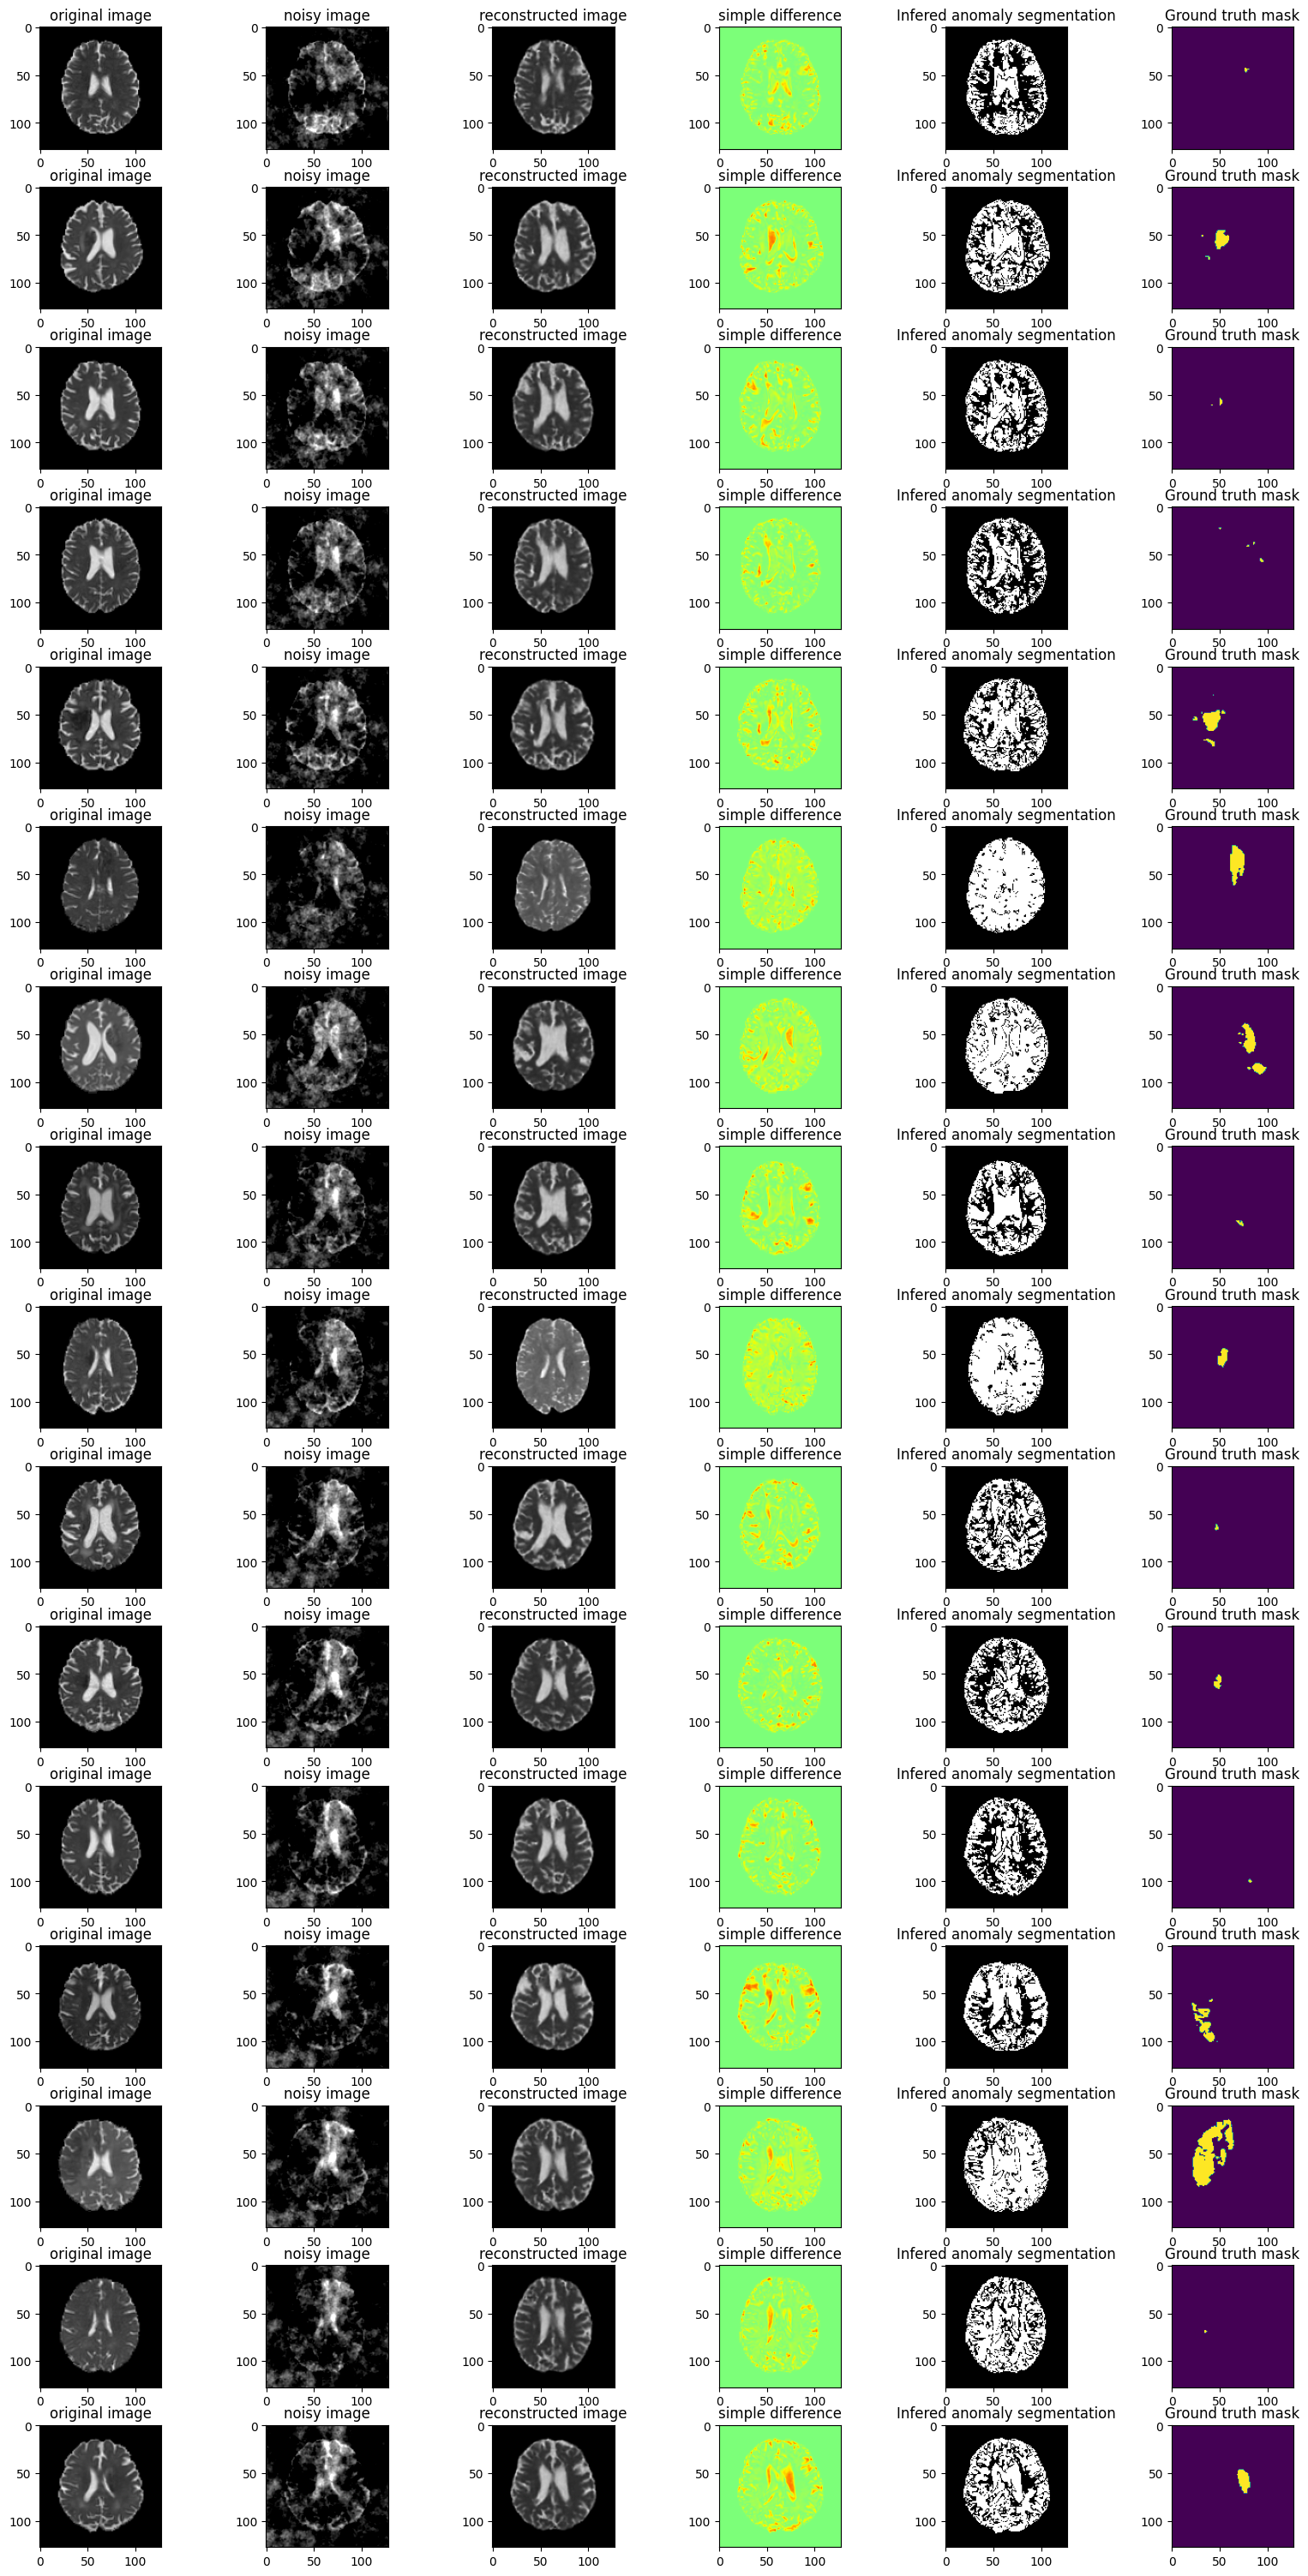

In [39]:
batch_to_visualize = 1

for i,(image_batch, mask_batch) in tqdm(enumerate(zip(test_anomaly_loader, test_masks_loader))): # i=6 batch is nice
    if i==batch_to_visualize:
        test_images = image_batch.to(device)
        test_masks = mask_batch.to(device)
        test_masks[test_masks>0.5] = 1.0
        test_masks[test_masks<=0.5] = 0.0

        with autocast(device_type=DEVICE_TYPE, enabled=True):
            infered_image, intermediates = my_sample(test_images, timesteps=best_num_timesteps, progress_bar=False)

        fig, axs = plt.subplots(ano_batch_size, 6, figsize=(16,30))
        plt.tight_layout()

        for j in range(ano_batch_size):

            axs[j, 0].title.set_text('original image')
            axs[j, 1].title.set_text('noisy image')
            axs[j, 2].title.set_text('reconstructed image')
            axs[j, 3].title.set_text('simple difference')
            axs[j, 4].title.set_text('Infered anomaly segmentation')
            axs[j, 5].title.set_text('Ground truth mask')

            axs[j, 0].imshow(test_images[j,0].cpu(), vmin=0, vmax=1, cmap="gray")
            axs[j, 1].imshow(intermediates[0][j,0].cpu(), vmin=0, vmax=1, cmap="gray")
            axs[j, 2].imshow(infered_image[j,0].cpu(), vmin=0, vmax=1, cmap="gray")
            axs[j, 3].imshow(np.abs(infered_image[j,0].cpu() - test_images[j,0].cpu()), vmin=-1, vmax=1, cmap="jet")
            axs[j, 4].imshow(torch.abs(infered_image[j,0].cpu() - test_images[j,0].cpu()) > best_threshold, cmap="gray")
            axs[j, 5].imshow(test_masks[j,0].cpu(), vmin=0, vmax=1, cmap="viridis")
    elif i==batch_to_visualize+1:
        break
            